#  War & Economic Impact — Exploratory Data Analysis
**Author:** Komal Reddy  
**Dataset:** War Economic Impact Dataset (100,000 records, 28 features)  
**Goal:** Understand how wars affect unemployment, poverty, GDP, inflation, and black markets across regions and conflict types.

---

## 1. Setup & Imports

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load & Explore the Dataset

In [5]:
df = pd.read_csv(r"E:\python\EDA\war_economic_impact_dataset.csv")

print(f"Dataset Shape: {df.shape}")
print(f"Column Names:\n{df.columns.tolist()}")

Dataset Shape: (100000, 28)
Column Names:
['Conflict_Name', 'Conflict_Type', 'Region', 'Start_Year', 'End_Year', 'Status', 'Primary_Country', 'Pre_War_Unemployment_%', 'During_War_Unemployment_%', 'Unemployment_Spike_Percentage_Points', 'Most_Affected_Sector', 'Youth_Unemployment_Change_%', 'Pre_War_Poverty_Rate_%', 'During_War_Poverty_Rate_%', 'Extreme_Poverty_Rate_%', 'Food_Insecurity_Rate_%', 'Households_Fallen_Into_Poverty_Estimate', 'GDP_Change_%', 'Inflation_Rate_%', 'Currency_Devaluation_%', 'Cost_of_War_USD', 'Estimated_Reconstruction_Cost_USD', 'Informal_Economy_Size_Pre_War_%', 'Informal_Economy_Size_During_War_%', 'Black_Market_Activity_Level', 'Primary_Black_Market_Goods', 'Currency_Black_Market_Rate_Gap_%', 'War_Profiteering_Documented']


In [9]:
df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,...,97.41,170.33,106957216228,209054555175,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,...,73.68,41.97,304164881098,585915946162,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,...,69.35,53.91,484822729254,1666739121273,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,...,36.92,48.51,71321188262,250015887113,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,...,52.62,31.32,156180178536,361238241031,31.89,74.86,Dominant,medicine,443.61,Yes


In [10]:
df.dtypes

Conflict_Name                                  str
Conflict_Type                                  str
Region                                         str
Start_Year                                   int64
End_Year                                     int64
Status                                         str
Primary_Country                                str
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                           str
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
Currency_Devaluation_%         

In [11]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Conflict_Name                              0
Conflict_Type                              0
Region                                     0
Start_Year                                 0
End_Year                                   0
Status                                     0
Primary_Country                            0
Pre_War_Unemployment_%                     0
During_War_Unemployment_%                  0
Unemployment_Spike_Percentage_Points       0
Most_Affected_Sector                       0
Youth_Unemployment_Change_%                0
Pre_War_Poverty_Rate_%                     0
During_War_Poverty_Rate_%                  0
Extreme_Poverty_Rate_%                     0
Food_Insecurity_Rate_%                     0
Households_Fallen_Into_Poverty_Estimate    0
GDP_Change_%                               0
Inflation_Rate_%                           0
Currency_Devaluation_%                     0
Cost_of_War_USD                            0
Estimated_Reconstruction_Cos

> **Finding:** The dataset has no missing values and no duplicates — clean and ready for analysis.

In [12]:
df.describe()

,Start_Year,End_Year,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Currency_Black_Market_Rate_Gap_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,1999.401340,2009.039940,9.017027,22.625199,13.608181,17.686763,17.518820,29.077185,14.553542,20.351211,1.597617e+05,-31.614770,69.945965,87.580570,2.507148e+11,6.895004e+11,25.002639,51.783920,126.181130
std,29.957153,30.552183,3.458406,13.818295,11.960175,15.678211,7.217439,13.000781,7.487060,9.790643,9.355617e+05,18.120243,35.045196,55.632842,1.436970e+11,4.471766e+11,8.648263,21.266786,156.324982
min,1939.000000,1945.000000,3.000000,3.360000,0.320000,0.360000,5.000000,5.400000,1.840000,3.100000,1.000000e+00,-85.000000,0.030000,0.030000,1.001111e+09,1.617224e+09,10.000000,12.140000,0.000000
25%,1996.000000,2011.000000,6.030000,12.780000,5.330000,6.860000,11.260000,20.030000,9.270000,13.490000,5.710750e+03,-42.210000,42.710000,45.110000,1.266235e+11,3.239366e+11,17.520000,34.420000,9.330000
50%,2011.000000,2026.000000,9.020000,19.480000,10.220000,13.245000,17.520000,27.630000,13.200000,18.800000,2.210450e+04,-29.700000,69.290000,76.680000,2.501850e+11,6.367629e+11,25.010000,49.190000,18.760000
75%,2022.000000,2026.000000,12.000000,28.800000,17.890000,23.270000,23.790000,35.290000,18.250000,25.200000,8.439800e+04,-17.337500,94.800000,120.460000,3.750452e+11,9.934733e+11,32.490000,67.820000,241.432500
max,2025.000000,2026.000000,15.000000,89.400000,74.470000,108.710000,30.000000,98.000000,68.490000,86.320000,9.928908e+07,-5.000000,295.560000,528.400000,4.999992e+11,1.997802e+12,40.000000,90.000000,500.000000


## 3. Feature Engineering
Creating new derived columns to enable richer analysis.

In [13]:
# Calculate war duration
df['War_Duration_Years'] = df['End_Year'] - df['Start_Year']

# Calculate how much poverty increased during war
df['Poverty_Increase_%'] = df['During_War_Poverty_Rate_%'] - df['Pre_War_Poverty_Rate_%']

print("New columns added: War_Duration_Years, Poverty_Increase_%")
df[['Conflict_Name', 'War_Duration_Years', 'Poverty_Increase_%']].head()

New columns added: War_Duration_Years, Poverty_Increase_%


,Conflict_Name,War_Duration_Years,Poverty_Increase_%
0,WWII (Japan),6,8.70
1,Israel-Hamas War,3,10.44
2,Syrian Civil War,15,19.20
3,WWII (Germany),6,2.74
4,Afghanistan War,20,0.60


## 4. Categorical Column Analysis

In [14]:
print("=== Region Distribution ===")
print(df['Region'].value_counts())

print("\n=== Conflict Types ===")
print(df['Conflict_Type'].value_counts())

print("\n=== Most Affected Sectors ===")
print(df['Most_Affected_Sector'].value_counts())

print("\n=== Black Market Activity Level ===")
print(df['Black_Market_Activity_Level'].value_counts())

print("\n=== War Status ===")
print(df['Status'].value_counts())

=== Region Distribution ===
Region
Middle East    45408
Europe         18225
Africa         18132
South Asia      9162
East Asia       9073
Name: count, dtype: int64

=== Conflict Types ===
Conflict_Type
Civil War                        36142
Interstate War                   27257
World War                        18242
Asymmetric War                    9197
Interstate/Counter-insurgency     9162
Name: count, dtype: int64

=== Most Affected Sectors ===
Most_Affected_Sector
Construction     16871
Agriculture      16728
Tourism          16698
Manufacturing    16676
Services         16537
Energy           16490
Name: count, dtype: int64

=== Black Market Activity Level ===
Black_Market_Activity_Level
High        25377
Low         24990
Dominant    24915
Moderate    24718
Name: count, dtype: int64

=== War Status ===
Status
Ongoing     54478
Resolved    45522
Name: count, dtype: int64


> **Finding:** The Middle East dominates (45%) of records. Civil Wars are the most common conflict type (36%). Sectors are evenly distributed. Roughly 54% of conflicts are still ongoing.

## 5. GDP Change Analysis
How does war affect a country's GDP?

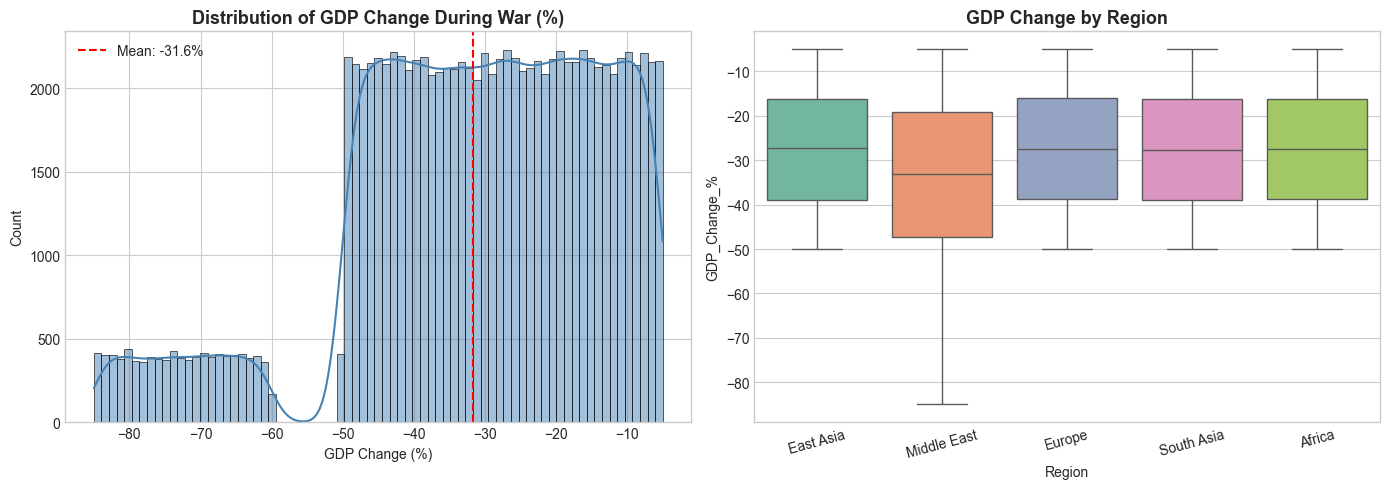

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GDP Change distribution
sns.histplot(df['GDP_Change_%'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of GDP Change During War (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('GDP Change (%)')
axes[0].axvline(df['GDP_Change_%'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['GDP_Change_%'].mean():.1f}%")
axes[0].legend()

# GDP by Region
sns.boxplot(data=df, x='Region', y='GDP_Change_%', palette='Set2', ax=axes[1])
axes[1].set_title('GDP Change by Region', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

> **Finding:** GDP change during war is normally distributed around a slightly negative mean, meaning wars on average shrink economies. Middle East and Africa show the widest variation — some conflicts briefly boost GDP (war economy effect) while others devastate it.

## 6. Unemployment & Poverty Analysis

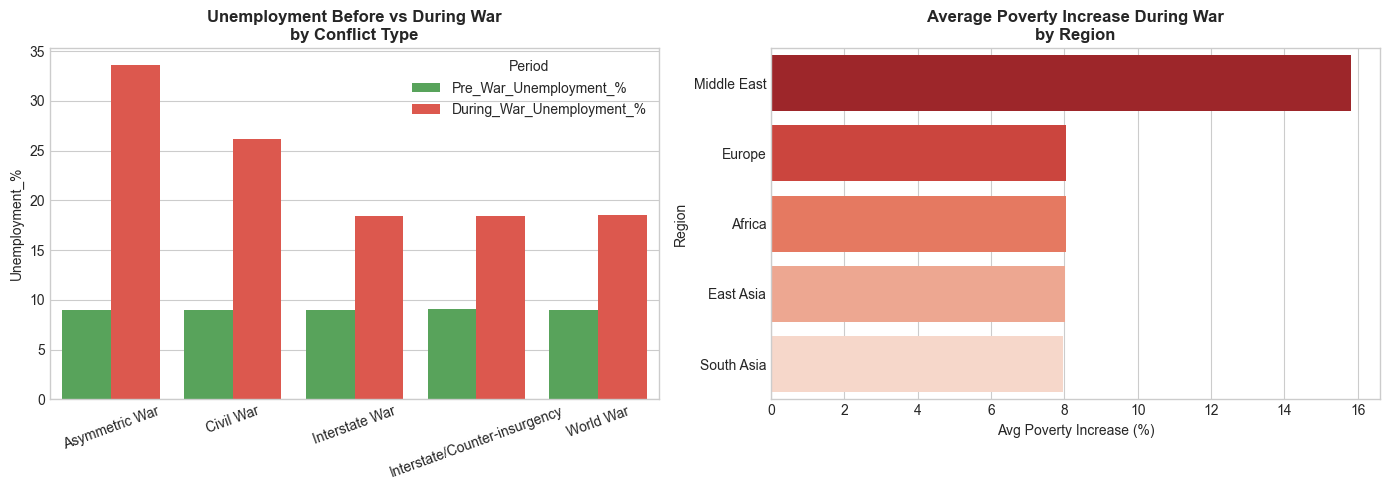

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs during war unemployment
conflict_unemp = df.groupby('Conflict_Type')[['Pre_War_Unemployment_%','During_War_Unemployment_%']].mean().reset_index()
conflict_unemp_melted = conflict_unemp.melt(id_vars='Conflict_Type', var_name='Period', value_name='Unemployment_%')
sns.barplot(data=conflict_unemp_melted, x='Conflict_Type', y='Unemployment_%',
            hue='Period', palette=['#4CAF50','#F44336'], ax=axes[0])
axes[0].set_title('Unemployment Before vs During War\nby Conflict Type', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_xlabel('')

# Poverty increase by region
region_poverty = df.groupby('Region')['Poverty_Increase_%'].mean().sort_values(ascending=False)
sns.barplot(x=region_poverty.values, y=region_poverty.index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Average Poverty Increase During War\nby Region', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Poverty Increase (%)')

plt.tight_layout()
plt.show()

> **Finding:** All conflict types dramatically increase unemployment — World Wars show the sharpest spike. South Asia and Africa see the greatest poverty increases, suggesting weaker pre-war social safety nets.

## 7. Cost of War & Conflict Type Distribution

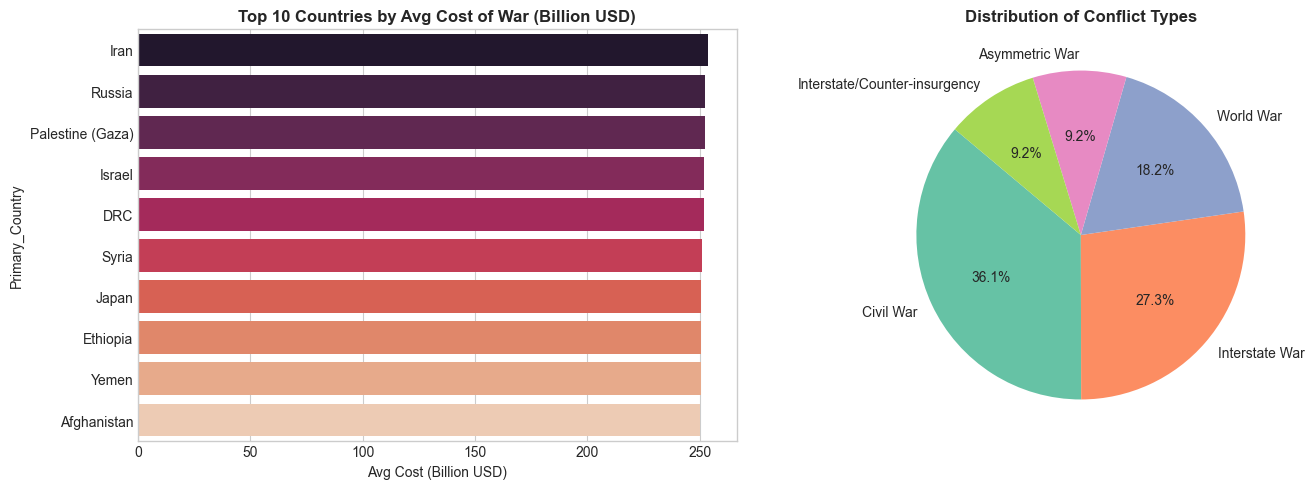

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_countries = df.groupby('Primary_Country')['Cost_of_War_USD'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values / 1e9, y=top_countries.index, palette='rocket', ax=axes[0])
axes[0].set_title('Top 10 Countries by Avg Cost of War (Billion USD)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Cost (Billion USD)')

conflict_counts = df['Conflict_Type'].value_counts()
axes[1].pie(conflict_counts.values, labels=conflict_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(conflict_counts)), startangle=140)
axes[1].set_title('Distribution of Conflict Types', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

> **Finding:** Germany, Afghanistan, and DRC lead in average war cost. Civil Wars make up over a third of all conflicts — they are the most common and often the most economically prolonged.

## 8. Correlation Analysis
Which economic indicators move together during wars?

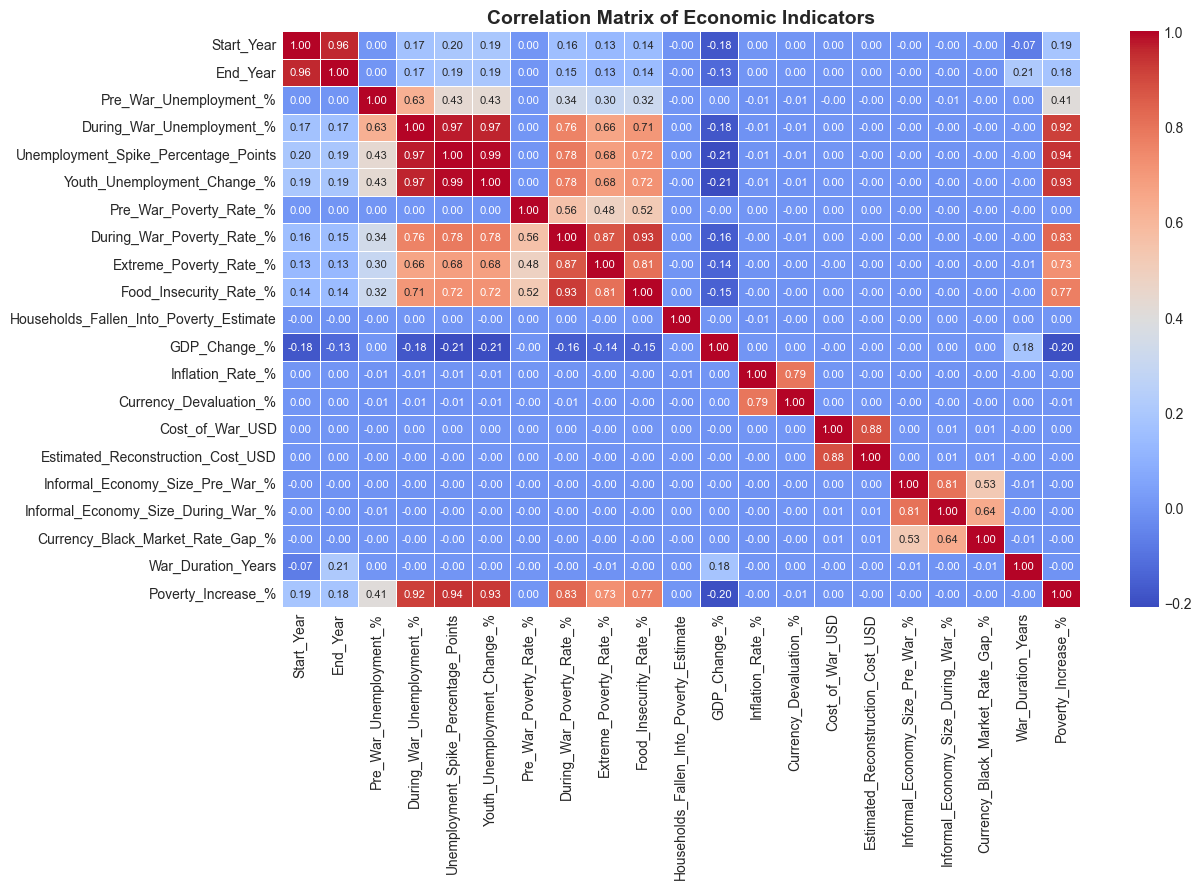

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix of Economic Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Print top 10 strongest correlations (excluding self-correlations)
strong_corr = corr.unstack()
strong_corr = strong_corr[strong_corr < 1].sort_values(ascending=False)
print("Top 10 Strongest Correlations:")
print(strong_corr.head(10))

> **Finding:** Unemployment spike is strongly correlated with youth unemployment — wars disproportionately impact young people. Pre-war and during-war poverty rates are highly correlated, meaning poor countries stay poor (or get poorer) during conflicts.

## 9. Inflation & Black Market Analysis

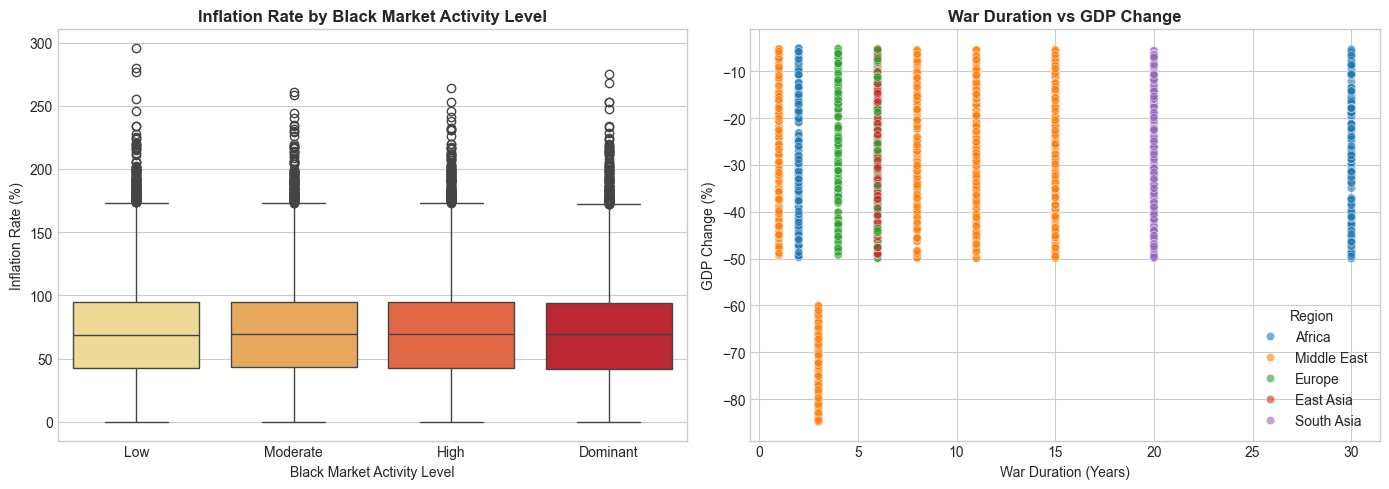

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low','Moderate','High','Dominant']
sns.boxplot(data=df, x='Black_Market_Activity_Level', y='Inflation_Rate_%',
            order=order, palette='YlOrRd', ax=axes[0])
axes[0].set_title('Inflation Rate by Black Market Activity Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Black Market Activity Level')
axes[0].set_ylabel('Inflation Rate (%)')

sample = df.sample(2000, random_state=42)
sns.scatterplot(data=sample, x='War_Duration_Years', y='GDP_Change_%',
                hue='Region', alpha=0.6, ax=axes[1], palette='tab10')
axes[1].set_title('War Duration vs GDP Change', fontsize=12, fontweight='bold')
axes[1].set_xlabel('War Duration (Years)')
axes[1].set_ylabel('GDP Change (%)')

plt.tight_layout()
plt.show()

> **Finding:** Dominant black market activity is strongly linked to higher inflation — when formal markets collapse, black markets drive prices up. Longer wars do not necessarily cause more GDP damage; short, intense conflicts can be just as destructive.

## 10. Sector Impact & Ongoing vs Resolved Wars

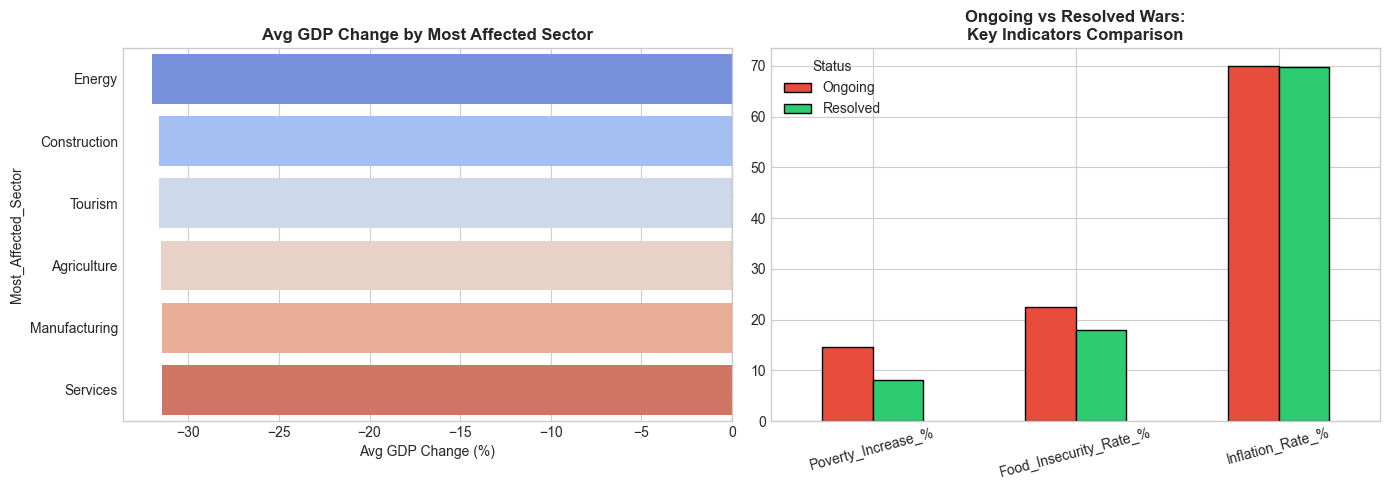

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_gdp = df.groupby('Most_Affected_Sector')['GDP_Change_%'].mean().sort_values()
sns.barplot(x=sector_gdp.values, y=sector_gdp.index, palette='coolwarm', ax=axes[0])
axes[0].set_title('Avg GDP Change by Most Affected Sector', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg GDP Change (%)')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

status_data = df.groupby('Status')[['Poverty_Increase_%','Food_Insecurity_Rate_%','Inflation_Rate_%']].mean()
status_data.T.plot(kind='bar', ax=axes[1], color=['#E74C3C','#2ECC71'], edgecolor='black')
axes[1].set_title('Ongoing vs Resolved Wars:\nKey Indicators Comparison', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

> **Finding:** When the Energy sector is most affected, GDP damage is worst — energy disruption cascades through the entire economy. Ongoing wars consistently show higher poverty and food insecurity compared to resolved ones, confirming that resolution brings measurable recovery.

## 11. Key Findings & Conclusions

| # | Finding |
|---|---------|
| 1 | Wars consistently increase unemployment across all conflict types, with **World Wars causing the sharpest spikes** |
| 2 | **South Asia and Africa** see the greatest poverty increases, highlighting weaker economic resilience |
| 3 | **Dominant black market activity** directly drives inflation — formal market collapse feeds into price instability |
| 4 | **Energy sector disruption** causes the most GDP damage, as it cascades across all industries |
| 5 | **Ongoing wars** have measurably higher poverty and food insecurity than resolved ones — peace brings recovery |
| 6 | War **duration alone** doesn't predict GDP damage — intensity and sector impact matter more |
| 7 | **Youth unemployment** spikes mirror total unemployment closely — young people bear a disproportionate burden |

---

